In [ ]:
!pip install duckdb

In [ ]:
!pip install pyarrow

In [61]:
from pathlib import Path
import pandas as pd
import numpy as np
import duckdb

In [62]:
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [63]:
import warnings
warnings.filterwarnings('ignore')

In [64]:
# Read json files
def read_yelp_json(filename: str) -> pd.DataFrame:
    """
    Read a Yelp Academic Dataset JSON file.

    Parameters
    ----------
    filename : str
        Example:
        'yelp_academic_dataset_review.json'

    Returns
    -------
    pd.DataFrame
    """
    # project root (one level above notebooks/)
    project_root = Path.cwd().parent

    file_path = project_root / "yelp_datasets" / "yelp_dataset" / filename

    return pd.read_json(file_path, lines=True)

In [65]:
#reviews = read_yelp_json("yelp_academic_dataset_review.json")
business = read_yelp_json("yelp_academic_dataset_business.json")
#users = read_yelp_json("yelp_academic_dataset_user.json")
tips = read_yelp_json("yelp_academic_dataset_tip.json")
checkins = read_yelp_json("yelp_academic_dataset_checkin.json")

In [66]:
tips.head()

,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban sandwiches,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


In [67]:
checkins.head()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020-07-24 22:42:27, 2020-10-24 21:36:13, 2020-12-09 21:23:33, 2021-01-20 17:34:57, 2021-04-30 21:02:03, 2021-05-25 21:16:54, 2021-08-06 21:08:08, 2021-10-02 15:15:42, 2021-11-11 16:23:50"
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011-07-18 22:30:31, 2012-09-07 20:28:50, 2013-03-27 15:57:36, 2013-08-13 00:31:34, 2013-08-13 00:31:48, 2013-09-23 17:39:38, 2013-11-18 06:34:08, 2014-04-12 23:04:47"
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012-03-11 10:30:02, 2012-04-24 07:07:59, 2012-04-24 07:43:31, 2013-05-25 16:41:10, 2014-05-02 15:49:55, 2014-09-18 02:28:23, 2014-11-10 15:16:43, 2015-09-27 13:18:32"
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014-09-30 14:41:47, 2014-10-23 18:22:28, 2015-04-27 19:55:00, 2015-09-21 12:52:09, 2015-10-01 12:46:16, 2015-10-22 13:35:04, 2016-01-14 12:27:43, 2016-02-01 15:15:07, 2016-02-11 12:22:47, 2016-03-31 23:15:46, 2016-04-11 13:11:34, 2016-05-25 12:44:11, 2016-06-27 15:46:11, 2016-06-30 15:14:28, 2016-07-28 14:15:59, 2016-09-22 20:05:06, 2016-11-16 19:00:11, 2016-12-27 14:36:14, 2017-01-24 20:18:16, 2017-02-21 16:01:49, 2017-03-21 14:08:44, 2017-05-21 16:07:21, 2017-08-07 14:17:39, 2021-06-21 19:59:50"


In [68]:
print(business.shape)
print(tips.shape)
print(checkins.shape)

(150346, 14)
(908915, 5)
(131930, 2)


In [69]:
business.business_id.nunique(), tips.business_id.nunique(), checkins.business_id.nunique()

(150346, 106193, 131930)

In [70]:
con = duckdb.connect()

reviews = con.execute("""
SELECT *
FROM read_json_auto('../yelp_datasets/yelp_dataset/yelp_academic_dataset_review.json')
LIMIT 3000000
""").fetchdf()

In [71]:
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.00,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.00,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.00,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with no expectations. Next to the Clarion Hotel.",2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.00,1,0,1,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.00,1,0,1,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too much cheese which I liked. Needed something else...pepper jelly maybe. Would like to see more menu options added such as salads w fun cheeses. Lots of beer and wine as well as limited cocktails. Next time I will try one of the draft wines.",2017-01-14 20:54:15


In [72]:
reviews.date.min(), reviews.date.max()

(Timestamp('2005-03-01 16:57:17'), Timestamp('2022-01-19 19:48:16'))

In [73]:
reviews.shape

(3000000, 9)

In [74]:
users = con.execute("""
SELECT *
FROM read_json_auto('../yelp_datasets/yelp_dataset/yelp_academic_dataset_user.json')
LIMIT 3000000
""").fetchdf()

In [75]:
users.shape

(1987897, 22)

In [76]:
users.columns

Index(['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny',
       'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot',
       'compliment_more', 'compliment_profile', 'compliment_cute',
       'compliment_list', 'compliment_note', 'compliment_plain',
       'compliment_cool', 'compliment_funny', 'compliment_writer',
       'compliment_photos'],
      dtype='object')

In [77]:
business.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [78]:
tips.columns

Index(['user_id', 'business_id', 'text', 'date', 'compliment_count'], dtype='object')

In [79]:
reviews.columns

Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='object')

In [80]:
business.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

## Dataset Preperation

In [81]:
%%time
# ============================================================
# 1. Prepare datasets
# ============================================================

# Convert date columns to datetime
reviews["date"] = pd.to_datetime(reviews["date"])
tips["date"] = pd.to_datetime(tips["date"])
users["yelping_since"] = pd.to_datetime(users["yelping_since"])


# Rename columns to avoid ambiguity after merging
business_clean = business.rename(columns={
    "name": "business_name",
    "stars": "business_stars",
    "review_count": "business_review_count"
})

user_clean = users.rename(columns={
    "name": "user_name",
    "review_count": "user_review_count",
    "average_stars": "user_average_stars"
})

review_clean = reviews.rename(columns={
    "stars": "review_stars",
    "useful": "review_useful",
    "funny": "review_funny",
    "cool": "review_cool",
    "text": "review_text",
    "date": "review_date"
})

tip_clean = tips.rename(columns={
    "text": "tip_text",
    "date": "tip_date",
    "compliment_count": "tip_compliment_count"
})

CPU times: user 589 ms, sys: 4.09 s, total: 4.68 s
Wall time: 19.3 s


In [82]:
%%time

# ============================================================
# 2. Aggregate tip information for each business
# ============================================================

# A business may have multiple tips.
# Aggregate them into a single record that can be joined
# with each review.

tips_agg = (
    tip_clean
    .groupby("business_id")
    .agg(
        tip_count=("tip_text", "count"),
        sample_tips=("tip_text", lambda x: " | ".join(x.dropna().head(3))),
        avg_tip_compliment=("tip_compliment_count", "mean"),
        latest_tip_date=("tip_date", "max")
    )
    .reset_index()
)

CPU times: user 4.2 s, sys: 422 ms, total: 4.62 s
Wall time: 5.3 s


In [83]:
%%time
# ============================================================
# 3. Build the modeling dataset
# ============================================================

# Review table is used as the primary fact table.
# We enrich each review with:
#   - Business information
#   - User information
#   - Aggregated business tips

df = (
    review_clean

    # Business information
    .merge(
        business_clean[
            [
                "business_id",
                "business_name",
                "city",
                "state",
                "latitude",
                "longitude",
                "business_stars",
                "business_review_count",
                "is_open",
                "attributes",
                "categories"
            ]
        ],
        on="business_id",
        how="left"
    )

    # User information
    .merge(
        user_clean[
            [
                "user_id",
                "user_name",
                "user_review_count",
                "yelping_since",
                "user_average_stars",
                "useful",
                "funny",
                "cool",
                "fans",
                "elite"
            ]
        ],
        on="user_id",
        how="left",
        suffixes=("", "_user")
    )

    # Aggregated tips
    .merge(
        tips_agg,
        on="business_id",
        how="left"
    )
)

CPU times: user 4.21 s, sys: 3.7 s, total: 7.91 s
Wall time: 10.5 s


In [84]:
df.columns

Index(['review_id', 'user_id', 'business_id', 'review_stars', 'review_useful',
       'review_funny', 'review_cool', 'review_text', 'review_date',
       'business_name', 'city', 'state', 'latitude', 'longitude',
       'business_stars', 'business_review_count', 'is_open', 'attributes',
       'categories', 'user_name', 'user_review_count', 'yelping_since',
       'user_average_stars', 'useful', 'funny', 'cool', 'fans', 'elite',
       'tip_count', 'sample_tips', 'avg_tip_compliment', 'latest_tip_date'],
      dtype='object')

In [85]:
df.shape

(3000000, 32)

In [86]:
df.head()

,review_id,user_id,business_id,review_stars,review_useful,review_funny,review_cool,review_text,review_date,business_name,city,state,latitude,longitude,business_stars,business_review_count,is_open,attributes,categories,user_name,user_review_count,yelping_since,user_average_stars,useful,funny,cool,fans,elite,tip_count,sample_tips,avg_tip_compliment,latest_tip_date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.00,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",2018-07-07 22:09:11,Turning Point of North Wales,North Wales,PA,40.21,-75.22,3.00,169,1,"{'NoiseLevel': 'u'average'', 'HasTV': 'False', 'RestaurantsAttire': ''casual'', 'BikeParking': 'False', 'Ambience': '{'touristy': False, 'hipster': False, 'romantic': False, 'divey': False, 'intimate': False, 'trendy': False, 'upscale': False, 'classy': False, 'casual': True}', 'WiFi': ''free'', 'DogsAllowed': 'False', 'Alcohol': ''none'', 'BusinessAcceptsCreditCards': 'True', 'RestaurantsGoodForGroups': 'True', 'RestaurantsPriceRange2': '2', 'RestaurantsReservations': 'False', 'WheelchairAccessible': 'True', 'BusinessAcceptsBitcoin': 'False', 'RestaurantsTableService': 'True', 'GoodForKids': 'True', 'Caters': 'False', 'HappyHour': 'False', 'RestaurantsDelivery': 'True', 'GoodForMeal': '{'dessert': False, 'latenight': False, 'lunch': True, 'dinner': False, 'brunch': True, 'breakfast': True}', 'OutdoorSeating': 'True', 'RestaurantsTakeOut': 'True', 'BusinessParking': '{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}'}","Restaurants, Breakfast & Brunch, Food, Juice Bars & Smoothies, American (New), Coffee & Tea, Sandwiches",Melanie,33.00,2016-01-13 17:20:44,4.06,32.00,3.00,8.00,0.00,,8.00,Food was fresh & well made. Service was good - we sat at the bar stools. | Get the fruit bruschetta! | Some of the worst service I ever had. Waited 20 minutes for someone to c,0.00,2021-12-23 01:44:27
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.00,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",2012-01-03 15:28:18,Body Cycle Spinning Studio,Philadelphia,PA,39.95,-75.17,5.00,144,0,"{'BusinessAcceptsCreditCards': 'True', 'GoodForKids': 'False', 'ByAppointmentOnly': 'False', 'BusinessParking': '{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}', 'BikeParking': 'True'}","Active Life, Cycling Classes, Trainers, Gyms, Fitness & Instruction",Erin,10.00,2011-03-07 19:45:15,4.30,6.00,1.00,2.00,0.00,,15.00,nina's class!! | Russel is awesome ! | 90 min spin,0.00,2017-06-13 01:37:13
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.00,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeñ

In [87]:

# Method for reducing the memory usage
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [88]:
df = reduce_mem_usage(df)

Mem. usage decreased to 454.90 Mb (37.9% reduction)


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   review_id              object        
 1   user_id                object        
 2   business_id            object        
 3   review_stars           float16       
 4   review_useful          int16         
 5   review_funny           int16         
 6   review_cool            int16         
 7   review_text            object        
 8   review_date            datetime64[us]
 9   business_name          object        
 10  city                   object        
 11  state                  object        
 12  latitude               float16       
 13  longitude              float16       
 14  business_stars         float16       
 15  business_review_count  int16         
 16  is_open                int8          
 17  attributes             object        
 18  categories            

In [90]:
df.describe()

,review_stars,review_useful,review_funny,review_cool,review_date,latitude,longitude,business_stars,business_review_count,is_open,user_review_count,yelping_since,user_average_stars,useful,funny,cool,fans,tip_count,avg_tip_compliment,latest_tip_date
count,"3,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00",3000000,"3,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00","2,999,988.00",2999988,"2,999,988.00","2,999,988.00","2,999,988.00","2,999,988.00","2,999,988.00","2,794,513.00","2,794,513.00",2794513
mean,NaN,1.16,0.32,0.49,2016-11-29 14:16:36.012519,NaN,NaN,NaN,348.15,0.82,NaN,2013-09-23 21:08:21.501214,NaN,430.68,177.55,291.44,NaN,NaN,0.00,2019-10-18 04:56:18.462688768
min,1.00,-1.00,-1.00,-1.00,2005-03-01 16:57:17,27.56,-120.12,1.00,5.00,0.00,0.00,2004-10-12 08:46:11,1.00,0.00,0.00,0.00,0.00,1.00,0.00,2009-04-29 14:13:41
25%,3.00,0.00,0.00,0.00,2014-12-17 21:59:01.250000,29.97,-90.31,3.50,44.00,1.00,7.00,2011-07-04 00:55:34.500000,3.40,4.00,0.00,0.00,0.00,6.00,0.00,2018-08-06 12:04:57
50%,4.00,0.00,0.00,0.00,2017-04-09 21:19:46.500000,38.62,-86.19,4.00,138.00,1.00,25.00,2013-08-12 15:58:25,3.88,19.00,3.00,5.00,0.00,20.00,0.00,2020-08-24 19:37:30
75%,5.00,1.00,0.00,0.00,2019-04-04 19:35:22.750000,39.94,-75.44,4.50,367.00,1.00,99.00,2015-10-27 21:15:01,4.29,113.00,25.00,40.00,4.00,54.00,0.01,2021-08-25 15:35:18
max,5.00,539.00,284.00,202.00,2022-01-19 19:48:16,53.66,-74.69,5.00,"5,070.00",1.00,"17,472.00",2022-01-19 17:15:47,5.00,"206,296.00","185,823.00","199,878.00","12,496.00","2,572.00",3.00,2022-01-19 20:38:55
std,0.00,2.91,1.58,1.96,NaN,0.00,0.00,0.00,616.00,0.38,0.00,NaN,0.00,"3,283.03","2,049.54","2,816.82",0.00,0.00,0.00,NaN


## Analyse

In [91]:
# ============================================================
# 1. Basic data quality overview
# ============================================================

print("Shape:", df.shape)
print("Unique reviews:", df["review_id"].nunique())
print("Unique users:", df["user_id"].nunique())
print("Unique businesses:", df["business_id"].nunique())

missing_values = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_values.columns = ["column", "missing_ratio"]
missing_values.head(10)

Shape: (3000000, 32)
Unique reviews: 3000000
Unique users: 1170815
Unique businesses: 71554


,column,missing_ratio
0,latest_tip_date,0.07
1,avg_tip_compliment,0.07
2,sample_tips,0.07
3,tip_count,0.07
4,attributes,0.03
5,categories,0.00
6,elite,0.00
7,fans,0.00
8,cool,0.00
9,funny,0.00


In [92]:
# Do NOT overwrite review_text with fillna on full dataframe
# Instead, calculate text length in a memory-friendlier way

df["review_char_count"] = df["review_text"].str.len().fillna(0).astype("int32")

df["review_word_count"] = (
    df["review_text"]
    .fillna("")
    .str.count(r"\S+")
    .astype("int32")
)

df[["review_word_count", "review_char_count"]].describe()

,review_word_count,review_char_count
count,"3,000,000.00","3,000,000.00"
mean,104.66,567.17
std,97.70,526.25
min,1.00,1.00
25%,42.00,229.00
50%,75.00,405.00
75%,133.00,720.00
max,"1,059.00","5,000.00"


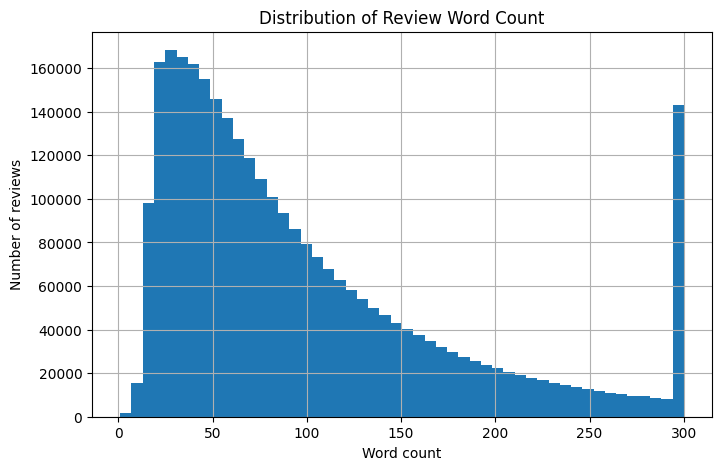

In [93]:
plt.figure(figsize=(8, 5))
df["review_word_count"].clip(upper=300).hist(bins=50)
plt.title("Distribution of Review Word Count")
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
plt.show()

In [94]:
# ============================================================
# 3. Rating distribution
# ============================================================

rating_dist = (
    df["review_stars"]
    .value_counts(normalize=True)
    .sort_index()
    .reset_index()
)

rating_dist.columns = ["review_stars", "ratio"]
rating_dist

,review_stars,ratio
0,1.00,0.15
1,2.00,0.08
2,3.00,0.10
3,4.00,0.21
4,5.00,0.46


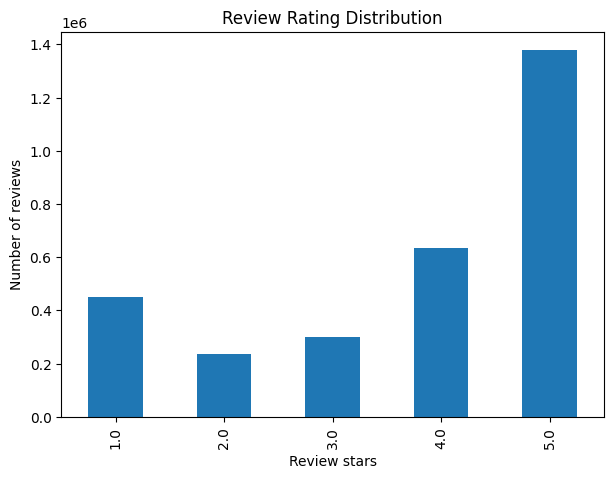

In [95]:
plt.figure(figsize=(7, 5))
df["review_stars"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Rating Distribution")
plt.xlabel("Review stars")
plt.ylabel("Number of reviews")
plt.show()

In [96]:
# ============================================================
# 4. Review length vs rating
# ============================================================
df["review_stars"] = df["review_stars"].astype("float32")
df["review_word_count"] = df["review_word_count"].astype("int32")

length_by_rating = (
    df.groupby("review_stars")["review_word_count"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

length_by_rating

,review_stars,count,mean,median,std
0,1.00,449753,133.57,96.00,124.53
1,2.00,234820,133.80,101.00,114.52
2,3.00,301483,123.90,95.00,104.41
3,4.00,635419,107.79,81.00,93.32
4,5.00,1378525,84.61,61.00,78.58


<Figure size 800x500 with 0 Axes>

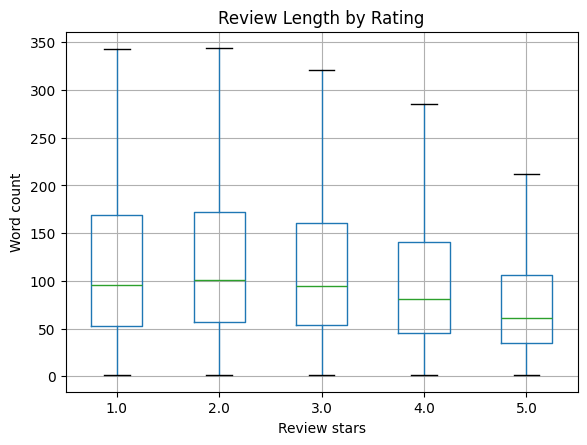

In [97]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count", by="review_stars", showfliers=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Review stars")
plt.ylabel("Word count")
plt.show()

In [98]:
# ============================================================
# 5. Create sentiment target
# ============================================================

df["target_sentiment"] = np.where(
    df["review_stars"] <= 2,
    "negative",
    np.where(df["review_stars"] == 3, "neutral", "positive")
)

df["target_sentiment"].value_counts(normalize=True)

target_sentiment
positive   0.67
negative   0.23
neutral    0.10
Name: proportion, dtype: float64

In [99]:
# ============================================================
# 6. TF-IDF keyword analysis by sentiment
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

df["review_stars"] = df["review_stars"].astype("float32")
df["review_word_count"] = df["review_word_count"].astype("int32")

sample_for_tfidf = df.sample(
    n=min(200_000, len(df)),
    random_state=42
).copy()

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=20
)

X_tfidf = vectorizer.fit_transform(sample_for_tfidf["review_text"])
terms = np.array(vectorizer.get_feature_names_out())


def top_tfidf_terms(label, top_n=25):
    # Convert pandas boolean Series to numpy array for scipy sparse indexing
    idx = (sample_for_tfidf["target_sentiment"] == label).to_numpy()

    # Calculate average TF-IDF score for the selected sentiment class
    mean_scores = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()

    # Get top terms
    top_idx = np.argsort(mean_scores)[::-1][:top_n]

    return pd.DataFrame({
        "term": terms[top_idx],
        "score": mean_scores[top_idx]
    })


top_positive_terms = top_tfidf_terms("positive")
top_neutral_terms = top_tfidf_terms("neutral")
top_negative_terms = top_tfidf_terms("negative")

top_negative_terms.head(10)

,term,score
0,food,0.03
1,service,0.03
2,just,0.02
3,place,0.02
4,time,0.02
5,like,0.02
6,order,0.02
7,told,0.02
8,don,0.02
9,said,0.02


In [100]:
top_positive_terms.head(10)

,term,score
0,great,0.04
1,food,0.03
2,good,0.03
3,place,0.03
4,service,0.02
5,best,0.02
6,time,0.02
7,love,0.02
8,delicious,0.02
9,amazing,0.02


<Figure size 800x500 with 0 Axes>

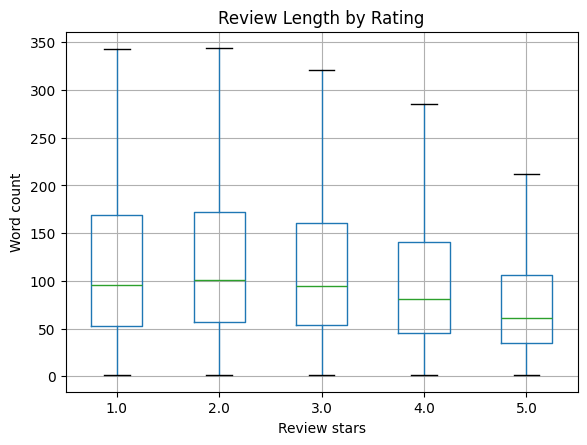

In [101]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count", by="review_stars", showfliers=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Review stars")
plt.ylabel("Word count")
plt.show()

In [102]:
# ============================================================
# 7. Category analysis
# ============================================================

category_df = df[
    ["business_id", "categories", "review_stars", "review_word_count", "target_sentiment"]
].dropna(subset=["categories"]).copy()

category_df["category"] = category_df["categories"].str.split(", ")
category_df = category_df.explode("category")

category_summary = (
    category_df
    .groupby("category")
    .agg(
        review_count=("review_stars", "count"),
        avg_rating=("review_stars", "mean"),
        avg_review_length=("review_word_count", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

category_summary = category_summary[category_summary["review_count"] >= 1000]
category_summary.sort_values("review_count", ascending=False).head(10)

,category,review_count,avg_rating,avg_review_length,negative_ratio
980,Restaurants,2036484,3.79,100.39,0.21
447,Food,789607,3.90,97.34,0.18
773,Nightlife,672769,3.79,105.90,0.20
102,Bars,639794,3.79,105.44,0.20
33,American (Traditional),435353,3.68,101.86,0.23
32,American (New),408599,3.82,108.99,0.19
162,Breakfast & Brunch,364519,3.87,98.81,0.18
998,Sandwiches,298113,3.87,92.75,0.19
401,Event Planning & Services,263826,3.71,116.63,0.23
1008,Seafood,256429,3.81,101.58,0.20


In [103]:
category_summary.sort_values("negative_ratio", ascending=False).head(10)

,category,review_count,avg_rating,avg_review_length,negative_ratio
1135,Television Service Providers,1962,1.68,132.45,0.82
614,Internet Service Providers,3639,1.81,132.08,0.79
1177,Truck Rental,1952,2.20,139.15,0.68
1188,University Housing,1357,2.28,178.11,0.65
741,Mortgage Lenders,1026,2.42,127.22,0.64
1134,Telecommunications,2484,2.50,126.39,0.61
908,Post Offices,2155,2.44,109.32,0.59
928,Property Management,5377,2.59,155.52,0.59
97,Banks & Credit Unions,3340,2.60,111.74,0.57
608,Insurance,2998,2.68,126.55,0.57


In [104]:
# ============================================================
# 8. City-level analysis
# ============================================================

city_summary = (
    df.groupby(["city", "state"])
    .agg(
        review_count=("review_id", "count"),
        business_count=("business_id", "nunique"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean()),
        avg_review_length=("review_word_count", "mean")
    )
    .reset_index()
)

city_summary = city_summary[city_summary["review_count"] >= 1000]
city_summary.sort_values("review_count", ascending=False).head(10)

,city,state,review_count,business_count,avg_rating,negative_ratio,avg_review_length
670,Philadelphia,PA,434583,7040,3.78,0.20,113.27
587,New Orleans,LA,274179,2975,3.96,0.16,100.59
888,Tampa,FL,191271,4325,3.74,0.24,104.19
576,Nashville,TN,185672,3301,3.81,0.21,104.27
926,Tucson,AZ,175600,4379,3.72,0.25,103.21
391,Indianapolis,IN,163363,3594,3.84,0.20,109.14
717,Reno,NV,150166,2835,3.75,0.24,110.50
764,Saint Louis,MO,111670,2398,3.86,0.19,110.78
778,Santa Barbara,CA,106250,1821,3.98,0.18,98.84
239,Edmonton,AB,45480,2463,3.61,0.22,134.39


In [105]:
city_summary.sort_values("negative_ratio", ascending=False).head(10)

,city,state,review_count,business_count,avg_rating,negative_ratio,avg_review_length
273,Fenton,MO,3129,136,2.80,0.50,118.26
281,Flourtown,PA,1087,28,2.85,0.48,112.23
85,Bridgeton,MO,1441,75,3.03,0.44,112.63
285,Fort Washington,PA,1219,32,3.12,0.41,128.24
482,Manchester,MO,1012,62,3.22,0.40,117.75
86,Bristol,PA,1192,60,3.15,0.40,119.86
534,Montgomeryville,PA,1101,49,3.17,0.40,113.50
930,Turnersville,NJ,1445,71,3.23,0.40,115.05
413,King Of Prussia,PA,3276,62,3.09,0.39,124.74
971,Warrington,PA,2778,95,3.19,0.39,103.92


In [106]:
# ============================================================
# 9. User behavior analysis
# ============================================================
df["user_review_count"] = df["user_review_count"].fillna(0).astype("float32")
df["review_stars"] = df["review_stars"].astype("float32")
df["review_word_count"] = df["review_word_count"].astype("int32")


df["user_experience_bucket"] = pd.cut(
    df["user_review_count"],
    bins=[0, 5, 20, 100, 500, np.inf],
    labels=["0-5", "6-20", "21-100", "101-500", "500+"]
)

user_behavior = (
    df.groupby("user_experience_bucket", observed=True)
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean()),
        avg_review_length=("review_word_count", "mean")
    )
    .reset_index()
)

user_behavior

,user_experience_bucket,review_count,avg_rating,negative_ratio,avg_review_length
0,0-5,604874,3.44,0.37,92.52
1,6-20,779846,3.76,0.26,88.93
2,21-100,872389,3.85,0.20,100.01
3,101-500,574181,3.90,0.13,130.34
4,500+,168670,3.87,0.10,157.50


<Figure size 800x500 with 0 Axes>

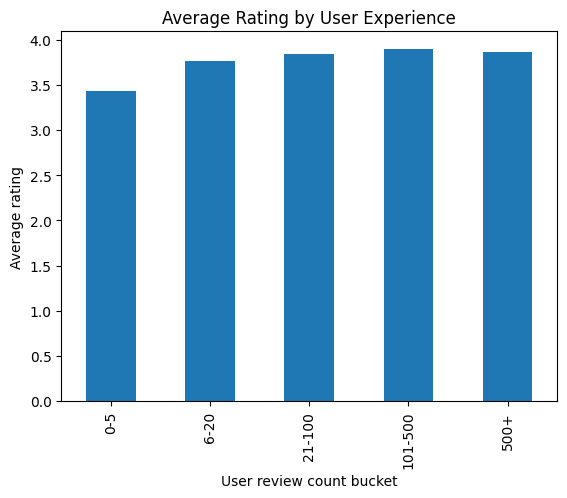

In [107]:
plt.figure(figsize=(8, 5))
user_behavior.plot(
    x="user_experience_bucket",
    y="avg_rating",
    kind="bar",
    legend=False
)
plt.title("Average Rating by User Experience")
plt.xlabel("User review count bucket")
plt.ylabel("Average rating")
plt.show()

In [108]:
# ============================================================
# 10. Business reputation gap
# ============================================================

df["rating_gap"] = df["review_stars"] - df["business_stars"]

rating_gap_summary = df["rating_gap"].describe()
rating_gap_summary

count   3,000,000.00
mean            0.00
std             1.29
min            -4.00
25%            -0.50
50%             0.50
75%             1.00
max             4.00
Name: rating_gap, dtype: float64

In [109]:
extreme_negative_gap = (
    df.sort_values("rating_gap")
    [
        [
            "business_name",
            "city",
            "state",
            "business_stars",
            "review_stars",
            "rating_gap",
            "review_text"
        ]
    ]
    .head(10)
)

extreme_negative_gap

,business_name,city,state,business_stars,review_stars,rating_gap,review_text
2443934,Lucent Skincare Santa Barbara,Santa Barbara,CA,5.00,1.00,-4.00,"I've gone here about 5 times over the past few years to get my eyebrows tinted. I originally only went here because it was inexpensive. I always ask for the lightest possible shade of brown because I have very blonde hair. Every time my eyebrows come out dark brown almost black and I am embarrassed to even go in public because it looks so un-natural. Natalie has always been very nice to me, the customer service is great, and the work environment is clean so I have returned hoping for better results. I scheduled an appointment for 10am Saturday morning and missed it because of a family emergency and Natalie charged me $40 without telling me. I will never return and I would not recommend Lucent spa to anyone I know."
2055669,Three Graces Coffee,Philadelphia,PA,5.00,1.00,-4.00,"One star for the way the shop looked. Can't comment on the coffee, because during a Philly heatwave they refuse to allow indoor seating. This is not CDC, or PA, or Philly Covid rule. It is just rudeness on the part of mgmt. This neighborhood locale is off our ""go to"" list."
2720514,Greg Avakian,Philadelphia,PA,5.00,1.00,-4.00,Initially responded with a quote and then completely disappeared. Disappointing and frustrating to just be ignored when trying to give someone work.
1826341,Primal Performance Spine and Sport,Saint Petersburg,FL,5.00,1.00,-4.00,I was really disappointed in this place. I feel it's extremely overpriced for the care you receive. You are charged top dollar & they don't even have a private room? I had to receive an adjustment while my chiropractor spoke to the other chiropractor & his patient about what weight they lifted at the gym. Also while listening to loud pop/hip hop music...not against that music but shouldn't it be relaxing music during adjustments??? They also double booked so you can stand around waiting while they can't even apologize...Totally disappointed & will never recommend this place...EVER!
2008559,Philadelphia Distilling,Philadelphia,PA,5.00,1.00,-4.00,Previously had great experiences here. However this past Saturday there was Terrible service. Arrived and the bar was empty and was denied seating.
533613,Food + Drink,Reno,NV,5.00,1.00,-4.00,Perfectly disastrous. I don't think they use the ingredients that Aaron used to use. And they really can't get their act together.
1093474,Brushfire Pottery Studio,Nashville,TN,5.00,1.00,-4.00,"I have been a loyal Brushfire customer since 1998. I have probably painted over 100 pieces over the years and generally always had a really amazing experience. The staff was always friendly, the selection good, the process quick and smooth, and I usually get my pieces back earlier than anticipated. However for my most recent experience about two weeks ago, disregard ALL of that. \n\nThe first thing I noticed was that the Halloween selection was piss poor at best. I went on October 4th, you'd think they would have Halloween items galore. The only real options were two large items both costing over $40 each. When I asked about the pumpkins with words on them, I was rudely told those were custom pieces and had to be pre-ordered. That information is fine, but she could have said it MUCH friendlier. The staff was the worst part about it all. They were RUDE, lazy, seemed annoyed anytime I asked for help, and generally seemed completely disinterested in being of assistance. They were eating while on the job, and I was even abruptly asked to move when I was looking at the stencils at the table directly by the stencils when they were making something out of clay. \n\nWhen I finished and asked how long my piece would take, I was given the usual estimate of a week. I said I hoped it might be finished 2 days early because I was leaving town and wanted to gift it to the person out of town I was seeing, and was told it most likely would be finished a little 

In [110]:
# ============================================================
# 11. Review usefulness analysis
# ============================================================

df["is_useful_review"] = (df["review_useful"] > 0).astype(int)

usefulness_summary = (
    df.groupby("is_useful_review")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        avg_review_length=("review_word_count", "mean"),
        avg_user_review_count=("user_review_count", "mean"),
        avg_business_stars=("business_stars", "mean")
    )
    .reset_index()
)

usefulness_summary

,is_useful_review,review_count,avg_rating,avg_review_length,avg_user_review_count,avg_business_stars
0,0,1654409,3.88,81.86,68.70,3.78
1,1,1345591,3.59,132.69,194.56,3.72


<Figure size 800x500 with 0 Axes>

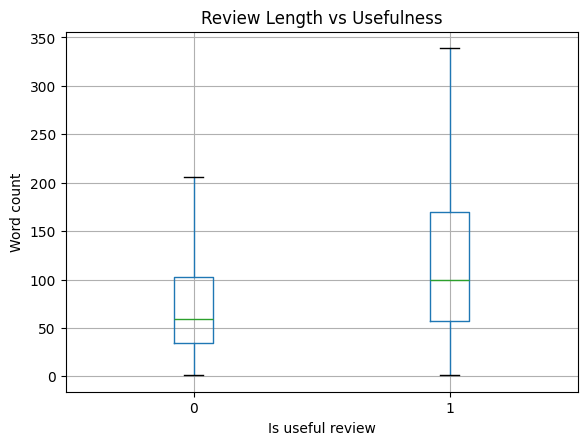

In [111]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count", by="is_useful_review", showfliers=False)
plt.title("Review Length vs Usefulness")
plt.suptitle("")
plt.xlabel("Is useful review")
plt.ylabel("Word count")
plt.show()

In [112]:
# ============================================================
# 12. Temporal analysis
# ============================================================

df["review_year"] = df["review_date"].dt.year
df["review_month"] = df["review_date"].dt.to_period("M").astype(str)
df["review_weekday"] = df["review_date"].dt.day_name()

monthly_summary = (
    df.groupby("review_month")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

monthly_summary.head()

,review_month,review_count,avg_rating,negative_ratio
0,2005-03,35,3.63,0.14
1,2005-04,15,4.27,0.07
2,2005-05,56,3.96,0.09
3,2005-06,20,3.95,0.15
4,2005-07,120,3.58,0.17


<Figure size 1200x500 with 0 Axes>

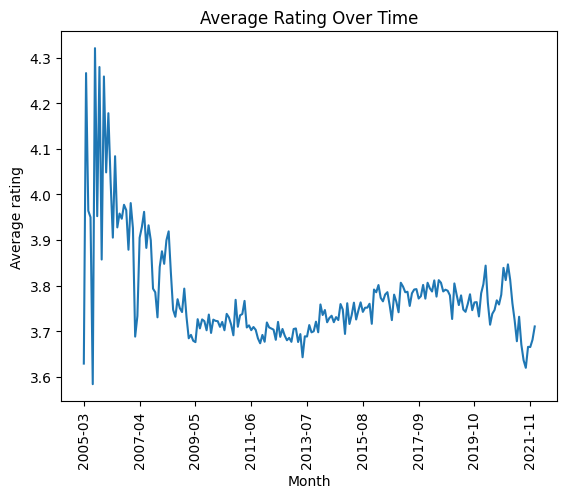

In [113]:
plt.figure(figsize=(12, 5))
monthly_summary.plot(x="review_month", y="avg_rating", legend=False)
plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average rating")
plt.xticks(rotation=90)
plt.show()

In [114]:
weekday_summary = (
    df.groupby("review_weekday")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_summary["review_weekday"] = pd.Categorical(
    weekday_summary["review_weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_summary.sort_values("review_weekday")

,review_weekday,review_count,avg_rating,negative_ratio
1,Monday,442748,3.73,0.23
5,Tuesday,405179,3.76,0.22
6,Wednesday,405427,3.77,0.22
4,Thursday,394011,3.78,0.22
0,Friday,403623,3.77,0.23
2,Saturday,456420,3.75,0.23
3,Sunday,492592,3.71,0.24


In [115]:
# ============================================================
# 13. Do tips add useful context?
# ============================================================

df["has_tips"] = df["tip_count"].fillna(0) > 0

tips_effect = (
    df.groupby("has_tips")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean()),
        avg_review_length=("review_word_count", "mean")
    )
    .reset_index()
)

tips_effect

,has_tips,review_count,avg_rating,negative_ratio,avg_review_length
0,False,205487,3.59,0.32,114.30
1,True,2794513,3.76,0.22,103.95


In [116]:
# ============================================================
# 15. Save modeling dataset
# ============================================================

model_dataset = df[
    [
        "review_id",
        "business_id",
        "user_id",
        "review_date",
        "review_stars",
        "target_sentiment",
        "review_text",
        "business_name",
        "city",
        "state",
        "categories",
        "business_stars",
        "business_review_count",
        "user_review_count",
        "user_average_stars",
        "review_word_count",
        "review_useful",
        "tip_count",
        "sample_tips",
        "rating_gap"
    ]
].copy()

model_dataset.shape

(3000000, 20)

In [117]:
df.columns

Index(['review_id', 'user_id', 'business_id', 'review_stars', 'review_useful',
       'review_funny', 'review_cool', 'review_text', 'review_date',
       'business_name', 'city', 'state', 'latitude', 'longitude',
       'business_stars', 'business_review_count', 'is_open', 'attributes',
       'categories', 'user_name', 'user_review_count', 'yelping_since',
       'user_average_stars', 'useful', 'funny', 'cool', 'fans', 'elite',
       'tip_count', 'sample_tips', 'avg_tip_compliment', 'latest_tip_date',
       'review_char_count', 'review_word_count', 'target_sentiment',
       'user_experience_bucket', 'rating_gap', 'is_useful_review',
       'review_year', 'review_month', 'review_weekday', 'has_tips'],
      dtype='object')

In [118]:
model_dataset.columns

Index(['review_id', 'business_id', 'user_id', 'review_date', 'review_stars',
       'target_sentiment', 'review_text', 'business_name', 'city', 'state',
       'categories', 'business_stars', 'business_review_count',
       'user_review_count', 'user_average_stars', 'review_word_count',
       'review_useful', 'tip_count', 'sample_tips', 'rating_gap'],
      dtype='object')